# UTS

Soal 1

In [5]:
import pandas as pd
import numpy as np
import re
import nltk
import gensim
from gensim import corpora
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from nltk.corpus import stopwords

nltk.download('stopwords')

# === Load Dataset ===
df = pd.read_csv('/content/Berita.csv')  # pastikan file sudah diunggah ke Colab
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...


preprocessing

In [15]:
import re
import pandas as pd

# --- Fungsi pembersihan teks ---
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()                        # ubah ke huruf kecil
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # hapus URL
    text = re.sub(r'<[^>]+>', ' ', text)            # hapus tag HTML
    text = re.sub(r'@\w+', ' ', text)               # hapus mention
    text = re.sub(r'#', ' ', text)                  # hapus simbol #
    text = re.sub(r'[^a-z\s]', ' ', text)           # hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()        # normalisasi spasi
    return text

# --- Membaca dataset ---
df = pd.read_csv('/content/Berita.csv')

# --- Terapkan pembersihan ---
df['clean_text'] = df['berita'].apply(clean_text)

# --- Tampilkan hasil dalam tabel (10 baris pertama) ---
print("=== Hasil Pembersihan Teks (10 Baris Pertama) ===")
df[['berita', 'clean_text']].head(10)


=== Hasil Pembersihan Teks (10 Baris Pertama) ===


,berita,clean_text
0,Menteri Koordinator (Menko) Bidang Perekonomia...,menteri koordinator menko bidang perekonomian ...
1,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",dalam rangka memeriahkan hari jadi ke pt surab...
2,Wacana Presiden Prabowo Subianto akan membentu...,wacana presiden prabowo subianto akan membentu...
3,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,bpjs ketenagakerjaan dan kementerian agama kem...
4,Pemerintah akan segera membentuk Satuan Tugas ...,pemerintah akan segera membentuk satuan tugas ...
5,Menko Bidang Infrastruktur dan Pembangunan Kew...,menko bidang infrastruktur dan pembangunan kew...
6,Kepala Badan Gizi Nasional Dadan Hindayana men...,kepala badan gizi nasional dadan hindayana men...
7,Menteri Koordinator Bidang Pangan Zulkifli Has...,menteri koordinator bidang pangan zulkifli has...
8,Uji coba alias commissioning pembangkit listri...,uji coba alias commissioning pembangkit listri...
9,Anak crazy rich pengusaha sawit Kalimantan Sam...,anak crazy rich pengusaha sawit kalimantan sam...


Ekstraksi fitur

In [17]:
# --- Import library tambahan untuk LDA ---
import gensim
from gensim import corpora
import numpy as np
import pandas as pd

# --- Pastikan kolom clean_text sudah ada ---
df[['clean_text']].head()

# --- Tokenisasi dari teks bersih ---
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# --- Membuat dictionary dan corpus untuk LDA ---
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# --- Membuat model LDA ---
num_topics = 5   # jumlah topik bisa diubah sesuai kebutuhan
lda_model = gensim.models.LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

# --- Tampilkan daftar topik dalam bentuk tabel ---
topics = lda_model.print_topics(num_words=5)
topics_df = pd.DataFrame(topics, columns=['Topik_ID', 'Kata_Kunci'])
print("=== Daftar Topik dari LDA ===")
display(topics_df)

# --- Konversi hasil LDA menjadi fitur numerik ---
def get_lda_features(corpus, model, num_topics):
    features = []
    for doc in corpus:
        topic_dist = [0] * num_topics
        for topic_id, prob in model.get_document_topics(doc):
            topic_dist[topic_id] = prob
        features.append(topic_dist)
    return np.array(features)

X_lda = get_lda_features(corpus, lda_model, num_topics)

# --- Simpan hasil fitur ke DataFrame ---
lda_features_df = pd.DataFrame(X_lda, columns=[f'Topic_{i+1}' for i in range(num_topics)])

# --- Gabungkan hasil fitur LDA dengan data asli (opsional) ---
df_lda = pd.concat([df[['clean_text']], lda_features_df], axis=1)

# --- Tampilkan hasil vektor fitur LDA dalam tabel (10 baris pertama) ---
print("=== Contoh Fitur LDA (10 Dokumen Pertama) ===")
display(df_lda.head(10))


=== Daftar Topik dari LDA ===


,Topik_ID,Kata_Kunci
0,0,"0.024*""di"" + 0.016*""yang"" + 0.013*""dan"" + 0.01..."
1,1,"0.020*""yang"" + 0.020*""di"" + 0.019*""dan"" + 0.01..."
2,2,"0.022*""yang"" + 0.021*""di"" + 0.020*""dan"" + 0.00..."
3,3,"0.021*""yang"" + 0.018*""di"" + 0.017*""dan"" + 0.01..."
4,4,"0.020*""di"" + 0.019*""yang"" + 0.016*""dan"" + 0.01..."


=== Contoh Fitur LDA (10 Dokumen Pertama) ===


,clean_text,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,menteri koordinator menko bidang perekonomian ...,0.0,0.000000,0.000000,0.384876,0.613659
1,dalam rangka memeriahkan hari jadi ke pt surab...,0.0,0.000000,0.000000,0.998409,0.000000
2,wacana presiden prabowo subianto akan membentu...,0.0,0.000000,0.061964,0.346521,0.590367
3,bpjs ketenagakerjaan dan kementerian agama kem...,0.0,0.000000,0.000000,0.795538,0.202262
4,pemerintah akan segera membentuk satuan tugas ...,0.0,0.000000,0.022372,0.411243,0.565064
5,menko bidang infrastruktur dan pembangunan kew...,0.0,0.000000,0.019932,0.276157,0.702787
6,kepala badan gizi nasional dadan hindayana men...,0.0,0.060727,0.000000,0.857775,0.080273
7,menteri koordinator bidang pangan zulkifli has...,0.0,0.105855,0.000000,0.811057,0.081949
8,uji coba alias commissioning pembangkit listri...,0.0,0.330857,0.000000,0.464915,0.202546
9,anak crazy rich pengusaha sawit kalimantan sam...,0.0,0.000000,0.000000,0.000000,0.988651


In [11]:
# --- Bagian 4: Split data ---

# Asumsi kolom label bernama 'kategori' atau 'label'
label_column = 'kategori' if 'kategori' in df.columns else 'label'

y = df[label_column]
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=42)

print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)

Data latih: (1200, 5)
Data uji: (300, 5)


In [12]:
# --- Bagian 5: Naive Bayes Classifier ---

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Hasil Naive Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


=== Hasil Naive Bayes ===
Akurasi: 0.7633333333333333
               precision    recall  f1-score   support

      Ekonomi       0.72      0.85      0.78        73
Internasional       0.81      0.62      0.70        84
     Nasional       0.59      0.66      0.62        70
     Olahraga       0.96      0.95      0.95        73

     accuracy                           0.76       300
    macro avg       0.77      0.77      0.76       300
 weighted avg       0.77      0.76      0.76       300



In [13]:
# --- Bagian 6: SVM Classifier ---

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== Hasil SVM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


=== Hasil SVM ===
Akurasi: 0.75
               precision    recall  f1-score   support

      Ekonomi       0.68      0.84      0.75        73
Internasional       0.78      0.61      0.68        84
     Nasional       0.59      0.63      0.61        70
     Olahraga       0.97      0.95      0.96        73

     accuracy                           0.75       300
    macro avg       0.76      0.75      0.75       300
 weighted avg       0.76      0.75      0.75       300



In [14]:
# --- Bagian 7: Perbandingan Hasil ---
print("Akurasi Naive Bayes :", round(accuracy_score(y_test, y_pred_nb)*100, 2), "%")
print("Akurasi SVM         :", round(accuracy_score(y_test, y_pred_svm)*100, 2), "%")

if accuracy_score(y_test, y_pred_svm) > accuracy_score(y_test, y_pred_nb):
    print("\n➡️ SVM memiliki performa lebih baik.")
else:
    print("\n➡️ Naive Bayes memiliki performa lebih baik.")


Akurasi Naive Bayes : 76.33 %
Akurasi SVM         : 75.0 %

➡️ Naive Bayes memiliki performa lebih baik.


In [21]:
# --- Import library tambahan untuk LDA ---
import gensim
from gensim import corpora
import numpy as np
import pandas as pd

# --- Pastikan kolom clean_text sudah ada ---
df[['clean_text']].head()

# --- Tokenisasi dari teks bersih ---
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# --- Membuat dictionary dan corpus untuk LDA ---
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# --- Membuat model LDA ---
num_topics = 20   # jumlah topik bisa diubah sesuai kebutuhan
lda_model = gensim.models.LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

# --- Tampilkan daftar topik dalam bentuk tabel ---
topics = lda_model.print_topics(num_words=20)
topics_df = pd.DataFrame(topics, columns=['Topik_ID', 'Kata_Kunci'])
print("=== Daftar Topik dari LDA ===")
display(topics_df)

# --- Konversi hasil LDA menjadi fitur numerik ---
def get_lda_features(corpus, model, num_topics):
    features = []
    for doc in corpus:
        topic_dist = [0] * num_topics
        for topic_id, prob in model.get_document_topics(doc):
            topic_dist[topic_id] = prob
        features.append(topic_dist)
    return np.array(features)

X_lda = get_lda_features(corpus, lda_model, num_topics)

# --- Simpan hasil fitur ke DataFrame ---
lda_features_df = pd.DataFrame(X_lda, columns=[f'Topic_{i+1}' for i in range(num_topics)])

# --- Gabungkan hasil fitur LDA dengan data asli (opsional) ---
df_lda = pd.concat([df[['clean_text']], lda_features_df], axis=1)

# --- Tampilkan hasil vektor fitur LDA dalam tabel (10 baris pertama) ---
print("=== Contoh Fitur LDA (10 Dokumen Pertama) ===")
display(df_lda.head(10))


=== Daftar Topik dari LDA ===


,Topik_ID,Kata_Kunci
0,0,"0.020*""indonesia"" + 0.020*""di"" + 0.017*""timnas..."
1,1,"0.021*""yang"" + 0.020*""di"" + 0.016*""dan"" + 0.01..."
2,2,"0.022*""di"" + 0.021*""yang"" + 0.021*""dan"" + 0.01..."
3,3,"0.024*""yang"" + 0.022*""dan"" + 0.015*""ini"" + 0.0..."
4,4,"0.023*""yang"" + 0.018*""di"" + 0.012*""dan"" + 0.01..."
5,5,"0.024*""di"" + 0.023*""dan"" + 0.019*""yang"" + 0.01..."
6,6,"0.030*""di"" + 0.022*""yang"" + 0.018*""dan"" + 0.01..."
7,7,"0.026*""red"" + 0.024*""sparks"" + 0.024*""poin"" + ..."
8,8,"0.023*""di"" + 0.019*""indonesia"" + 0.017*""ke"" + ..."
9,9,"0.018*""yang"" + 0.016*""dan"" + 0.013*""dalam"" + 0..."


=== Contoh Fitur LDA (10 Dokumen Pertama) ===


,clean_text,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_11,Topic_12,Topic_13,Topic_14,Topic_15,Topic_16,Topic_17,Topic_18,Topic_19,Topic_20
0,menteri koordinator menko bidang perekonomian ...,0.0,0.000000,0.000000,0.000000,0.972395,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.025451,0.0,0.0,0.0
1,dalam rangka memeriahkan hari jadi ke pt surab...,0.0,0.357202,0.000000,0.492697,0.000000,0.148441,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,wacana presiden prabowo subianto akan membentu...,0.0,0.000000,0.020832,0.058874,0.518090,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.262692,0.0,0.0,0.0,0.137402,0.0,0.0,0.0
3,bpjs ketenagakerjaan dan kementerian agama kem...,0.0,0.000000,0.000000,0.205936,0.089897,0.701115,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,pemerintah akan segera membentuk satuan tugas ...,0.0,0.000000,0.000000,0.000000,0.907835,0.000000,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.089241,0.0,0.0,0.0
5,menko bidang infrastruktur dan pembangunan kew...,0.0,0.000000,0.000000,0.096241,0.616871,0.174538,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.011952,0.0,0.0,0.0
6,kepala badan gizi nasional dadan hindayana men...,0.0,0.389484,0.000000,0.000000,0.000000,0.000000,0.025084,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.582892,0.0,0.0,0.0
7,menteri koordinator bidang pangan zulkifli has...,0.0,0.303188,0.000000,0.075998,0.012588,0.133963,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.472177,0.0,0.0,0.0
8,uji coba alias commissioning pembangkit listri...,0.0,0.000000,0.000000,0.000000,0.000000,0.996085,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
9,anak crazy rich pengusaha sawit kalimantan sam...,0.0,0.031020,0.000000,0.000000,0.060274,0.905686,0.000000,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [28]:
from sklearn.model_selection import train_test_split

# --- Kolom target (label) ---
y = df['kategori']  # ubah sesuai nama kolom label kamu

# --- Split data (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    lda_features_df, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
# --- Bagian 5: Naive Bayes Classifier ---

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Hasil Naive Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


=== Hasil Naive Bayes ===
Akurasi: 0.7766666666666666
               precision    recall  f1-score   support

      Ekonomi       0.72      0.89      0.80        75
Internasional       0.78      0.68      0.73        75
     Nasional       0.69      0.61      0.65        75
     Olahraga       0.92      0.92      0.92        75

     accuracy                           0.78       300
    macro avg       0.78      0.78      0.77       300
 weighted avg       0.78      0.78      0.77       300



In [33]:
# --- Bagian 6: SVM Classifier ---

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== Hasil SVM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== Hasil SVM ===
Akurasi: 0.8033333333333333
               precision    recall  f1-score   support

      Ekonomi       0.73      0.93      0.82        75
Internasional       0.83      0.71      0.76        75
     Nasional       0.72      0.61      0.66        75
     Olahraga       0.95      0.96      0.95        75

     accuracy                           0.80       300
    macro avg       0.81      0.80      0.80       300
 weighted avg       0.81      0.80      0.80       300



In [39]:
# --- Import library tambahan untuk LDA ---
import gensim
from gensim import corpora
import numpy as np
import pandas as pd

# --- Pastikan kolom clean_text sudah ada ---
df[['clean_text']].head()

# --- Tokenisasi dari teks bersih ---
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# --- Membuat dictionary dan corpus untuk LDA ---
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# --- Membuat model LDA ---
num_topics = 50  # jumlah topik bisa diubah sesuai kebutuhan
lda_model = gensim.models.LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

# --- Tampilkan daftar topik dalam bentuk tabel ---
topics = lda_model.print_topics(num_words=50)
topics_df = pd.DataFrame(topics, columns=['Topik_ID', 'Kata_Kunci'])
print("=== Daftar Topik dari LDA ===")
display(topics_df)

# --- Konversi hasil LDA menjadi fitur numerik ---
def get_lda_features(corpus, model, num_topics):
    features = []
    for doc in corpus:
        topic_dist = [0] * num_topics
        for topic_id, prob in model.get_document_topics(doc):
            topic_dist[topic_id] = prob
        features.append(topic_dist)
    return np.array(features)

X_lda = get_lda_features(corpus, lda_model, num_topics)

# --- Simpan hasil fitur ke DataFrame ---
lda_features_df = pd.DataFrame(X_lda, columns=[f'Topic_{i+1}' for i in range(num_topics)])

# --- Gabungkan hasil fitur LDA dengan data asli (opsional) ---
df_lda = pd.concat([df[['clean_text']], lda_features_df], axis=1)

# --- Tampilkan hasil vektor fitur LDA dalam tabel (10 baris pertama) ---
print("=== Contoh Fitur LDA (10 Dokumen Pertama) ===")
display(df_lda.head(10))


=== Daftar Topik dari LDA ===


,Topik_ID,Kata_Kunci
0,19,"0.025*""negara"" + 0.014*""tinggal"" + 0.013*""bamb..."
1,40,"0.028*""di"" + 0.021*""itu"" + 0.017*""laut"" + 0.01..."
2,25,"0.025*""yang"" + 0.023*""di"" + 0.018*""dan"" + 0.01..."
3,22,"0.012*""serangan"" + 0.010*""siber"" + 0.009*""itu""..."
4,1,"0.021*""yang"" + 0.019*""dan"" + 0.015*""di"" + 0.01..."
5,27,"0.023*""di"" + 0.018*""yang"" + 0.017*""dan"" + 0.01..."
6,49,"0.024*""di"" + 0.021*""pagar"" + 0.018*""itu"" + 0.0..."
7,45,"0.020*""di"" + 0.016*""ke"" + 0.016*""yang"" + 0.014..."
8,39,"0.031*""red"" + 0.029*""sparks"" + 0.025*""poin"" + ..."
9,12,"0.046*""di"" + 0.027*""banjir"" + 0.025*""yang"" + 0..."


=== Contoh Fitur LDA (10 Dokumen Pertama) ===


,clean_text,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_41,Topic_42,Topic_43,Topic_44,Topic_45,Topic_46,Topic_47,Topic_48,Topic_49,Topic_50
0,menteri koordinator menko bidang perekonomian ...,0.0,0.000000,0.057367,0.000000,0.940335,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,dalam rangka memeriahkan hari jadi ke pt surab...,0.0,0.000000,0.000000,0.195578,0.000000,0.802545,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,wacana presiden prabowo subianto akan membentu...,0.0,0.000000,0.346417,0.066660,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bpjs ketenagakerjaan dan kementerian agama kem...,0.0,0.000000,0.000000,0.113920,0.507719,0.374990,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,pemerintah akan segera membentuk satuan tugas ...,0.0,0.000000,0.000000,0.000000,0.828604,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,menko bidang infrastruktur dan pembangunan kew...,0.0,0.000000,0.000000,0.099817,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,kepala badan gizi nasional dadan hindayana men...,0.0,0.000000,0.079110,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.011448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,menteri koordinator bidang pangan zulkifli has...,0.0,0.047788,0.165987,0.000000,0.000000,0.159158,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,uji coba alias commissioning pembangkit listri...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.521712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,anak crazy rich pengusaha sawit kalimantan sam...,0.0,0.106357,0.042042,0.000000,0.000000,0.672886,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
# --- Bagian 4: Split data ---

# Asumsi kolom label bernama 'kategori' atau 'label'
label_column = 'kategori' if 'kategori' in df.columns else 'label'

y = df[label_column]
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size=0.2, random_state=42)

print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)

Data latih: (1200, 50)
Data uji: (300, 50)


In [41]:
# --- Bagian 5: Naive Bayes Classifier ---

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Hasil Naive Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


=== Hasil Naive Bayes ===
Akurasi: 0.8833333333333333
               precision    recall  f1-score   support

      Ekonomi       0.80      0.90      0.85        73
Internasional       0.91      0.93      0.92        84
     Nasional       0.84      0.73      0.78        70
     Olahraga       1.00      0.96      0.98        73

     accuracy                           0.88       300
    macro avg       0.88      0.88      0.88       300
 weighted avg       0.89      0.88      0.88       300



In [42]:
# --- Bagian 6: SVM Classifier ---

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== Hasil SVM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== Hasil SVM ===
Akurasi: 0.8766666666666667
               precision    recall  f1-score   support

      Ekonomi       0.78      0.89      0.83        73
Internasional       0.92      0.93      0.92        84
     Nasional       0.81      0.74      0.78        70
     Olahraga       1.00      0.93      0.96        73

     accuracy                           0.88       300
    macro avg       0.88      0.87      0.87       300
 weighted avg       0.88      0.88      0.88       300



soal 2

In [51]:
# --- 1. Import Library ---
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- 2. Load File CSV dari /content ---
file_path = "/content/spam.csv"  # pastikan file ada di folder content
data = pd.read_csv(file_path, encoding='latin-1')

# Ambil kolom Text saja
data = data[['Text']].dropna()
print("Data awal:")
display(data.head())


Data awal:


,Text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."


Pembersihan Teks

In [52]:
# --- Stopwords manual ---
stop_words = set([
    "a","an","the","and","or","is","are","was","were","be","been","in","on","at",
    "to","for","of","by","with","as","that","this","it","from","but","not",
    "can","will","just","you","your","i","me","my","we","our","they","their"
])

# --- Fungsi pembersihan teks ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# --- Terapkan pembersihan ---
data['clean_text'] = data['Text'].astype(str).apply(clean_text)
print("\nContoh teks setelah dibersihkan:")
display(data[['Text','clean_text']].head())



Contoh teks setelah dibersihkan:


,Text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only bug...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think he goes usf he lives around her...


TF IDF Vertorization

In [53]:
def vectorize_text(data, max_features=1000):
    vectorizer = TfidfVectorizer(max_features=max_features)
    X_tfidf = vectorizer.fit_transform(data['clean_text'])
    return X_tfidf, vectorizer

X_tfidf, vectorizer = vectorize_text(data)
print(f"\nDimensi TF-IDF matrix: {X_tfidf.shape}")



Dimensi TF-IDF matrix: (5572, 1000)


K Means Clustering

In [54]:
def kmeans_clustering(X, k=3, random_state=42):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(X)
    return kmeans, clusters

k = 3
kmeans_model, clusters = kmeans_clustering(X_tfidf, k)
data['Cluster'] = clusters


Evaluasi Silhouette Score

In [55]:
def evaluate_silhouette(X, clusters):
    score = silhouette_score(X, clusters)
    print(f"\nSilhouette Score: {score:.4f}")
    return score

evaluate_silhouette(X_tfidf, clusters)



Silhouette Score: 0.0086


0.008618194914247415

Kata Dominan Tiap Cluster

In [56]:
def top_terms_per_cluster(kmeans, vectorizer, n_terms=10):
    terms = vectorizer.get_feature_names_out()
    result = {}
    for i, center in enumerate(kmeans.cluster_centers_):
        top_idx = center.argsort()[-n_terms:][::-1]
        result[f"Cluster {i}"] = [terms[j] for j in top_idx]
    return result

top_words = top_terms_per_cluster(kmeans_model, vectorizer)
print("\n=== Kata Dominan per Cluster ===")
for cluster, words in top_words.items():
    print(f"{cluster}: {', '.join(words)}")



=== Kata Dominan per Cluster ===
Cluster 0: im, sorry, later, ill, call, now, home, going, so, if
Cluster 1: call, free, now, claim, mobile, prize, have, txt, won, urgent
Cluster 2: have, ok, do, no, so, its, get, how, what, ltgt


Visualisasi Hasil dengan PCA

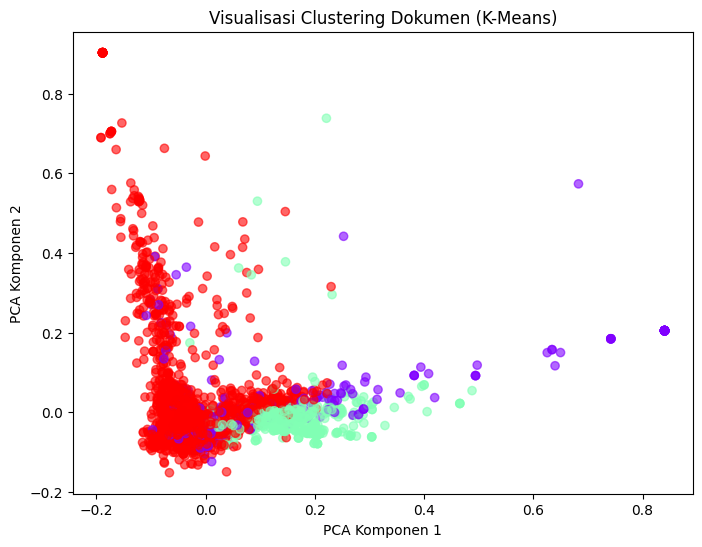

In [57]:
def plot_clusters_pca(X, clusters):
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X.toarray())
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='rainbow', alpha=0.6)
    plt.title("Visualisasi Clustering Dokumen (K-Means)")
    plt.xlabel("PCA Komponen 1")
    plt.ylabel("PCA Komponen 2")
    plt.show()

plot_clusters_pca(X_tfidf, clusters)


Hasil Cluster

In [58]:
def contoh_cluster(data, k):
    print("\n=== Contoh Email Tiap Cluster ===")
    for i in range(k):
        print(f"\nCluster {i}:")
        print(data[data['Cluster']==i]['Text'].head(3).to_string(index=False))

contoh_cluster(data, k)



=== Contoh Email Tiap Cluster ===

Cluster 0:
I'm gonna be home soon and i don't want to talk...
 IÛ÷m going to try for 2 months ha ha only joking
Just forced myself to eat a slice. I'm really n...

Cluster 1:
Free entry in 2 a wkly comp to win FA Cup final...
WINNER!! As a valued network customer you have ...
Had your mobile 11 months or more? U R entitled...

Cluster 2:
Go until jurong point, crazy.. Available only i...
                     Ok lar... Joking wif u oni...
 U dun say so early hor... U c already then say...
